In [1]:
import os
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import time
import tm
import tqdm
import copy
import sys
import datasetutils
plt.style.use('dark_background') # i prefer this color scheme but need to install. coment if not working

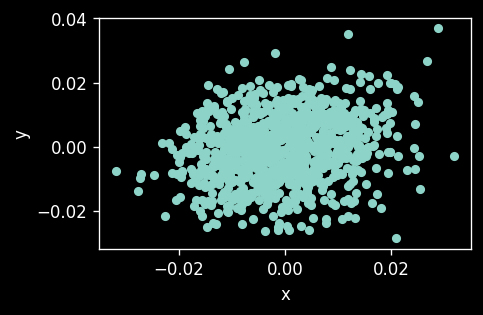

In [2]:
# 1 - CREATE DATA
# the idea is to create a dataframe with variables started with x and target returns started with y
# columns then can be x1, x_1, x2, xsomething ... and y1, y, y2, y_3
# index should be a datetime 
# this is the part where we spend most time researching :)
# lets generate some synthetic data 
n = 1000
x = np.random.normal(0, 0.01, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,0.01,n)
df = pd.DataFrame()
df['x'] = x
df['y'] = y
df.index = pd.date_range('2000-01-01', freq = 'D', periods = n)
df.plot.scatter('x', 'y')
plt.show()


In [3]:
# 2 - CREATE TM OBJECTS
# since we are dealing with a single dataset lets keep this simple 
# you can inspect the package code to get a better idea
# but this should be enough to get you started with some real examples
tm_data = tm.Data.from_df(df)

# now we define the model
# a model is a sequential application of transformations to data, a base model and how that
#   model is used to allocate capital
# most likely you want to focus on the base model and some simple transforms (that we ignore now)
#   as allocation must be a "solved" problem

# tm.base contains the models! you can check the abstract class BaseModel and how the 
#   others are build to create you own probabilist structures (aka models)
# lets use a linear regression with optimal allocation (why use another anyway..)
base_model = tm.base.LinRegr()
alloc = tm.allocation.Optimal()
model = tm.Model(base_model = base_model, allocation = alloc)
model.estimate(tm_data)
model.view()



* Model *
** Linear Regression **
Weights:  [-0.0003124   0.22441025]
Variance:  9.804993679451594e-05


k:  37.23465970241976
Weight mean:  [0.]
external multiplier:  1
leverage scale:  12.411553234139921




100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 91.15it/s]

Post process for key data


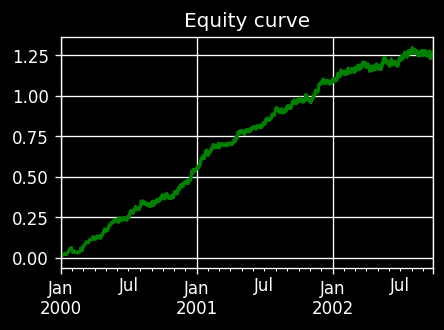

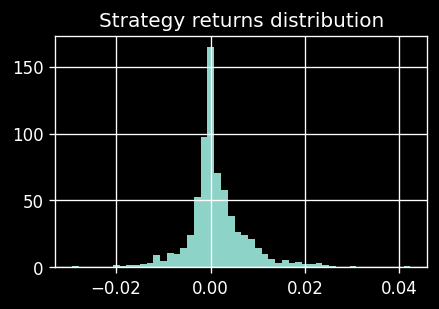

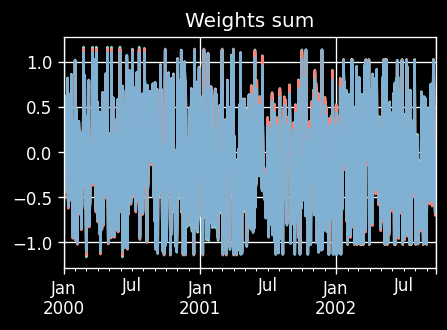

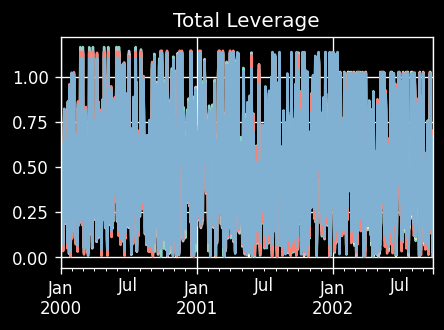

** ACCEPT STRATEGY from normal approximation of bootstrap Sharpe [alpha = 5e-05]**


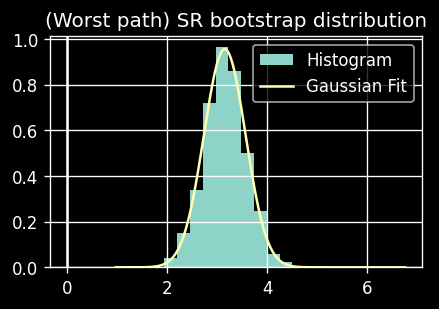


** PERFORMANCE SUMMARY **

Return:  0.3144972320778567
Standard deviation:  0.09921310327322326
Sharpe:  3.1699162882927046



{'strategy':               path_1    path_2    path_3    path_4    path_5
 2000-01-01  0.003490  0.003291  0.003297  0.003545  0.003392
 2000-01-02  0.004590  0.005148  0.005173  0.004439  0.005102
 2000-01-03  0.000037  0.000051  0.000051  0.000034  0.000049
 2000-01-04  0.003716  0.003469  0.003474  0.003783  0.003584
 2000-01-05 -0.000604 -0.000863 -0.000871 -0.000533 -0.000816
 ...              ...       ...       ...       ...       ...
 2002-09-22 -0.002275 -0.002379 -0.002659 -0.002836 -0.002461
 2002-09-23 -0.000677 -0.000747 -0.000928 -0.001057 -0.000786
 2002-09-24  0.008928  0.009086  0.009563  0.009775  0.009316
 2002-09-25  0.009263  0.009446  0.009987  0.010243  0.009691
 2002-09-26  0.000105  0.000072 -0.000009 -0.000074  0.000062
 
 [1000 rows x 5 columns],
 'leverage':               path_1    path_2    path_3    path_4    path_5
 2000-01-01  0.512755  0.483567  0.484364  0.520792  0.498390
 2000-01-02  0.259494  0.290989  0.292401  0.250918  0.288394
 2000-01-03  0.085

In [4]:
# 3 - RUN CVBT
# this part is always the same and is easy
paths = tm.cvbt(
        dataset = tm_data, 
        modelset = model,            
        n_paths = 5,
        k_folds = 4, 
        seq_path = False, 
        start_fold = 0, 
        burn_fraction = 0.1, 
        min_burn_points = 3,
        view_after_estimate = False
        )
paths.post_process(pct_fee = 0)

In [5]:
x = np.random.normal(0,1,(10,3))
q = np.quantile(np.abs(x), 0.8, axis = 0, method = 'closest_observation')
# now, if abs(x) along axis 0 is larger than the respective quantile we clip it

x

array([[-0.06239405, -1.25249364, -1.0554813 ],
       [-1.86904028, -0.08116521,  0.03111053],
       [-0.04586569,  0.62712907, -0.74166346],
       [ 0.49364692, -0.59239399, -0.08918949],
       [-0.79755155, -0.15212338, -0.69622955],
       [ 1.25406208,  0.91045361,  0.76223813],
       [ 1.97648353,  2.30921517,  0.56761319],
       [ 2.68148847,  0.85350375, -1.93177628],
       [ 0.16874034,  0.52266859, -0.43259779],
       [-0.47910892, -1.37536882, -1.15734168]])

In [6]:
q = np.quantile(np.abs(x), 0.8, axis = 0, method = 'closest_observation')
q

array([1.86904028, 1.25249364, 1.0554813 ])

In [7]:
np.clip(x, -q, q)


array([[-0.06239405, -1.25249364, -1.0554813 ],
       [-1.86904028, -0.08116521,  0.03111053],
       [-0.04586569,  0.62712907, -0.74166346],
       [ 0.49364692, -0.59239399, -0.08918949],
       [-0.79755155, -0.15212338, -0.69622955],
       [ 1.25406208,  0.91045361,  0.76223813],
       [ 1.86904028,  1.25249364,  0.56761319],
       [ 1.86904028,  0.85350375, -1.0554813 ],
       [ 0.16874034,  0.52266859, -0.43259779],
       [-0.47910892, -1.25249364, -1.0554813 ]])